# Analysis of Octo (L1 larva) synapses

In [2]:
import h5py
import pandas as pd
import glob
import os
import numpy as np

In [3]:
def load_hdf5(inputfilename, dataset):
    f = h5py.File(inputfilename, 'r')
    offset = (0, 0, 0)
    if dataset in f:
        data = f[dataset][:]
        if 'offset' in f[dataset].attrs.keys():
            offset = f[dataset].attrs['offset']
        print(dataset, data.shape, data.dtype)
    else:
        data = None
        print(dataset, 'does not exist')
    f.close()
    return data, offset

def load_zarr(inputfilename, dataset):
    import zarr
    f = zarr.open(inputfilename, mode='r')
    offset = (0, 0, 0)
    if dataset in f:
        data = f[dataset][:]
        if 'offset' in f[dataset].attrs.keys():
            offset = f[dataset].attrs['offset']
        print(dataset, data.shape, data.dtype)
    else:
        data = None
        print(dataset, 'does not exist')
    return data, offset


In [9]:
# load the raw volume to check the bounds
data_path = "/Volumes/SamiaSan/PhD_Data/Synapses/octo"
hdf_files = glob.glob(f'{data_path}/*.hdf', recursive=True) + glob.glob(f'{data_path}/*.hdf5', recursive=True) + glob.glob(f'{data_path}/*.h5', recursive=True)
print(f"all files {hdf_files}")
shapes = {}
# load the first file
filename = hdf_files[0]
print(f"filename {filename}")
raw_dataset = 'volumes/raw'
raw, offset = load_hdf5(filename, raw_dataset)
print(f"raw shape {raw.shape} offset {offset}")
shapes[filename] = raw.shape

# load the rest of the files
for filename in hdf_files[1:]:
    print(f"filename {filename}")
    raw, offset = load_hdf5(filename, raw_dataset)
    print(f"raw shape {raw.shape} offset {offset}")
    shapes[filename] = raw.shape

all files ['/Volumes/SamiaSan/PhD_Data/Synapses/octo/octo_cube1_8083_8765_y5878_6542_z4697_5319.hdf', '/Volumes/SamiaSan/PhD_Data/Synapses/octo/octo_cube3_calyx_5603_6267_y3254_3890_z7464_8163.hdf', '/Volumes/SamiaSan/PhD_Data/Synapses/octo/octo_cube2_12485_13164_y6231_6901_z3971_4640.hdf']
filename /Volumes/SamiaSan/PhD_Data/Synapses/octo/octo_cube1_8083_8765_y5878_6542_z4697_5319.hdf
volumes/raw (622, 664, 682) uint8
raw shape (622, 664, 682) offset [0 0 0]
filename /Volumes/SamiaSan/PhD_Data/Synapses/octo/octo_cube3_calyx_5603_6267_y3254_3890_z7464_8163.hdf
volumes/raw (699, 636, 664) uint8
raw shape (699, 636, 664) offset [0 0 0]
filename /Volumes/SamiaSan/PhD_Data/Synapses/octo/octo_cube2_12485_13164_y6231_6901_z3971_4640.hdf
volumes/raw (669, 670, 679) uint8
raw shape (669, 670, 679) offset [0 0 0]


In [ ]:
# Calculate the dimensions of each dataset in microns
def calculate_microns(shape, voxel_size):
    return [dim * voxel_size / 1000 for dim in shape]

# Calculate microns for each dataset from shapes above
microns = [calculate_microns(shape, 8) for shape in shapes.values()]

# Calculate the mean micron of all datasets
mean_micron = np.mean(microns, axis=0)

print(f"Microns of each dataset(zyx): {microns}")
print(f"Mean micron of all datasets (zyx): {mean_micron}")

Microns of each dataset(zyx): [[4.976, 5.312, 5.456], [5.592, 5.088, 5.312], [5.352, 5.36, 5.432]]
Mean micron of all datasets (zyx): [5.30666667 5.25333333 5.4       ]


In [ ]:
# Find synapses in a given dataset

def find_synapses(filename, res=(8, 8, 8), roi=None):
    if filename.lower().endswith((".h5", ".hdf", ".hdf5")):
        locs, offsets = load_hdf5(filename, 'annotations/locations')
    elif filename.lower().endswith(".zarr"):
        locs, offsets = load_zarr(filename, 'annotations/locations')

    offset = 0
    offsets = [i / j for i, j in zip(offsets, res)]
    locs = [loc + np.array(offsets, dtype=np.float32) for loc in locs]

    # Verify the bounds of the original data in nm
    raw_data_bounds = (np.min(locs, axis=0), np.max(locs, axis=0))
    print(f"Raw data bounds in nm: {raw_data_bounds}")

    if filename.lower().endswith((".h5", ".hdf", ".hdf5")):
        partners, offset = load_hdf5(filename, 'annotations/presynaptic_site/partners')
        annotation_ids, offset = load_hdf5(filename, 'annotations/ids')
    elif filename.lower().endswith(".zarr"):
        partners, offset = load_zarr(filename, 'annotations/presynaptic_site/partners')
        annotation_ids, offset = load_zarr(filename, 'annotations/ids')

    synapses = []
    for (pre, post) in partners:
        pre_indices = np.where(annotation_ids == pre)[0]
        post_indices = np.where(annotation_ids == post)[0]

        if len(pre_indices) == 0 or len(post_indices) == 0:
            print(f"Skipping pair (pre: {pre}, post: {post}) - not found in annotation_ids")
            continue
        pre_index = int(pre_indices[0])
        post_index = int(post_indices[0])

        pre_site = locs[pre_index]
        post_site = locs[post_index]


        if roi is not None:
            if (roi[0].start <= post_site[0] <= roi[0].stop and
                roi[1].start <= post_site[1] <= roi[1].stop and
                roi[2].start <= post_site[2] <= roi[2].stop):
                synapses.append((pre, post, pre_site, post_site))
        else:
            synapses.append((pre, post, pre_site, post_site))

        # pre_site = locs[pre_index]
        # post_site = locs[post_index]

        # if roi is not None:
        #     if (roi[0].start <= post_site[0] <= roi[0].stop and
        #             roi[1].start <= post_site[1] <= roi[1].stop and
        #             roi[2].start <= post_site[2] <= roi[2].stop):
        #         synapses.append((pre, post, pre_site, post_site))
        # else:
        #     synapses.append((pre, post, pre_site, post_site))

    return synapses

# List of HDF files to process
# Use glob to read all .hdf, .hdf5, and .h5 files, ignoring case
data_path = "/Volumes/SamiaSan/PhD_Data/Synapses/octo"
hdf_files = glob.glob(f'{data_path}/*.hdf', recursive=True) + glob.glob(f'{data_path}/*.hdf5', recursive=True) + glob.glob(f'{data_path}/*.h5', recursive=True)
print(hdf_files)

filename = hdf_files[0]
synapses = find_synapses(filename)
print(synapses[0])
print(len(synapses))

[]


IndexError: list index out of range

In [7]:
# Function to save synapses to CSV
def save_synapses_to_csv(synapses, filename):
    df = pd.DataFrame(synapses, columns=['pre_neuron', 'post_neuron', 'pre_z', 'pre_y', 'pre_x', 'post_z', 'post_y', 'post_x'])
    csv_filename = os.path.splitext(filename)[0] + '_synapses.csv'
    df.to_csv(csv_filename, index=False)
    print(f"Saved synapses to {csv_filename}")

# Process each file and save synapses to CSV
for filename in hdf_files:
    synapses = find_synapses(filename)
    synapses_flat = [(pre, post, pre_site[2], pre_site[1], pre_site[0], post_site[2], post_site[1], post_site[0]) for pre, post, pre_site, post_site in synapses]
    save_synapses_to_csv(synapses_flat, filename)

annotations/locations (1084, 3) float32
Raw data bounds in nm: (array([ 0., 24., 32.], dtype=float32), array([4976., 5312., 5304.], dtype=float32))
annotations/presynaptic_site/partners (542, 2) uint32
annotations/ids (1084,) int64
Saved synapses to /Volumes/SamiaSan/PhD_Data/Synapses/octo/octo_cube1_8083_8765_y5878_6542_z4697_5319_synapses.csv
annotations/locations (1700, 3) float32
Raw data bounds in nm: (array([0., 0., 0.], dtype=float32), array([5592., 5088., 5312.], dtype=float32))
annotations/presynaptic_site/partners (850, 2) uint32
annotations/ids (1700,) int64
Saved synapses to /Volumes/SamiaSan/PhD_Data/Synapses/octo/octo_cube3_calyx_5603_6267_y3254_3890_z7464_8163_synapses.csv
annotations/locations (1740, 3) float32
Raw data bounds in nm: (array([0., 0., 0.], dtype=float32), array([5352., 5360., 5432.], dtype=float32))
annotations/presynaptic_site/partners (870, 2) uint32
annotations/ids (1740,) int64
Saved synapses to /Volumes/SamiaSan/PhD_Data/Synapses/octo/octo_cube2_1248

In [5]:
# Read synapse data back into a DataFrame
synapse_data = []

for filename in hdf_files:
    csv_filename = os.path.splitext(filename)[0] + '_synapses.csv'
    if os.path.exists(csv_filename):
        df = pd.read_csv(csv_filename)
        synapse_data.append(df)

# Concatenate all DataFrames into one
df = pd.concat(synapse_data, ignore_index=True)
print(df.head())
print(f"shape of all_synapses_df {df.shape}")

NameError: name 'hdf_files' is not defined

In [10]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
# set the style
plt.style.use(['seaborn-v0_8-whitegrid', 'seaborn-v0_8-paper'])
mpl.rcParams.update({
    'font.family': 'Arial',
    'font.size': 12,
    'axes.linewidth': 1.5,
    'axes.labelsize': 14,
    'axes.titlesize': 16,
    'xtick.major.width': 1.5,
    'ytick.major.width': 1.5,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 12,
    'legend.frameon': False,
    'figure.dpi': 300,
    'axes.spines.top': False,
    'axes.spines.right': False
})

# Set color palette (Nature-style)
colors = ['#E64B35', '#4DBBD5', '#00A087', '#3C5488', '#F39B7F']
sns.set_palette(colors)

shape of all_synapse df (2262, 8)
Mean: 2.7
Median: 2.0
Mode: 2.0
Min: 1.0
Max: 10.0


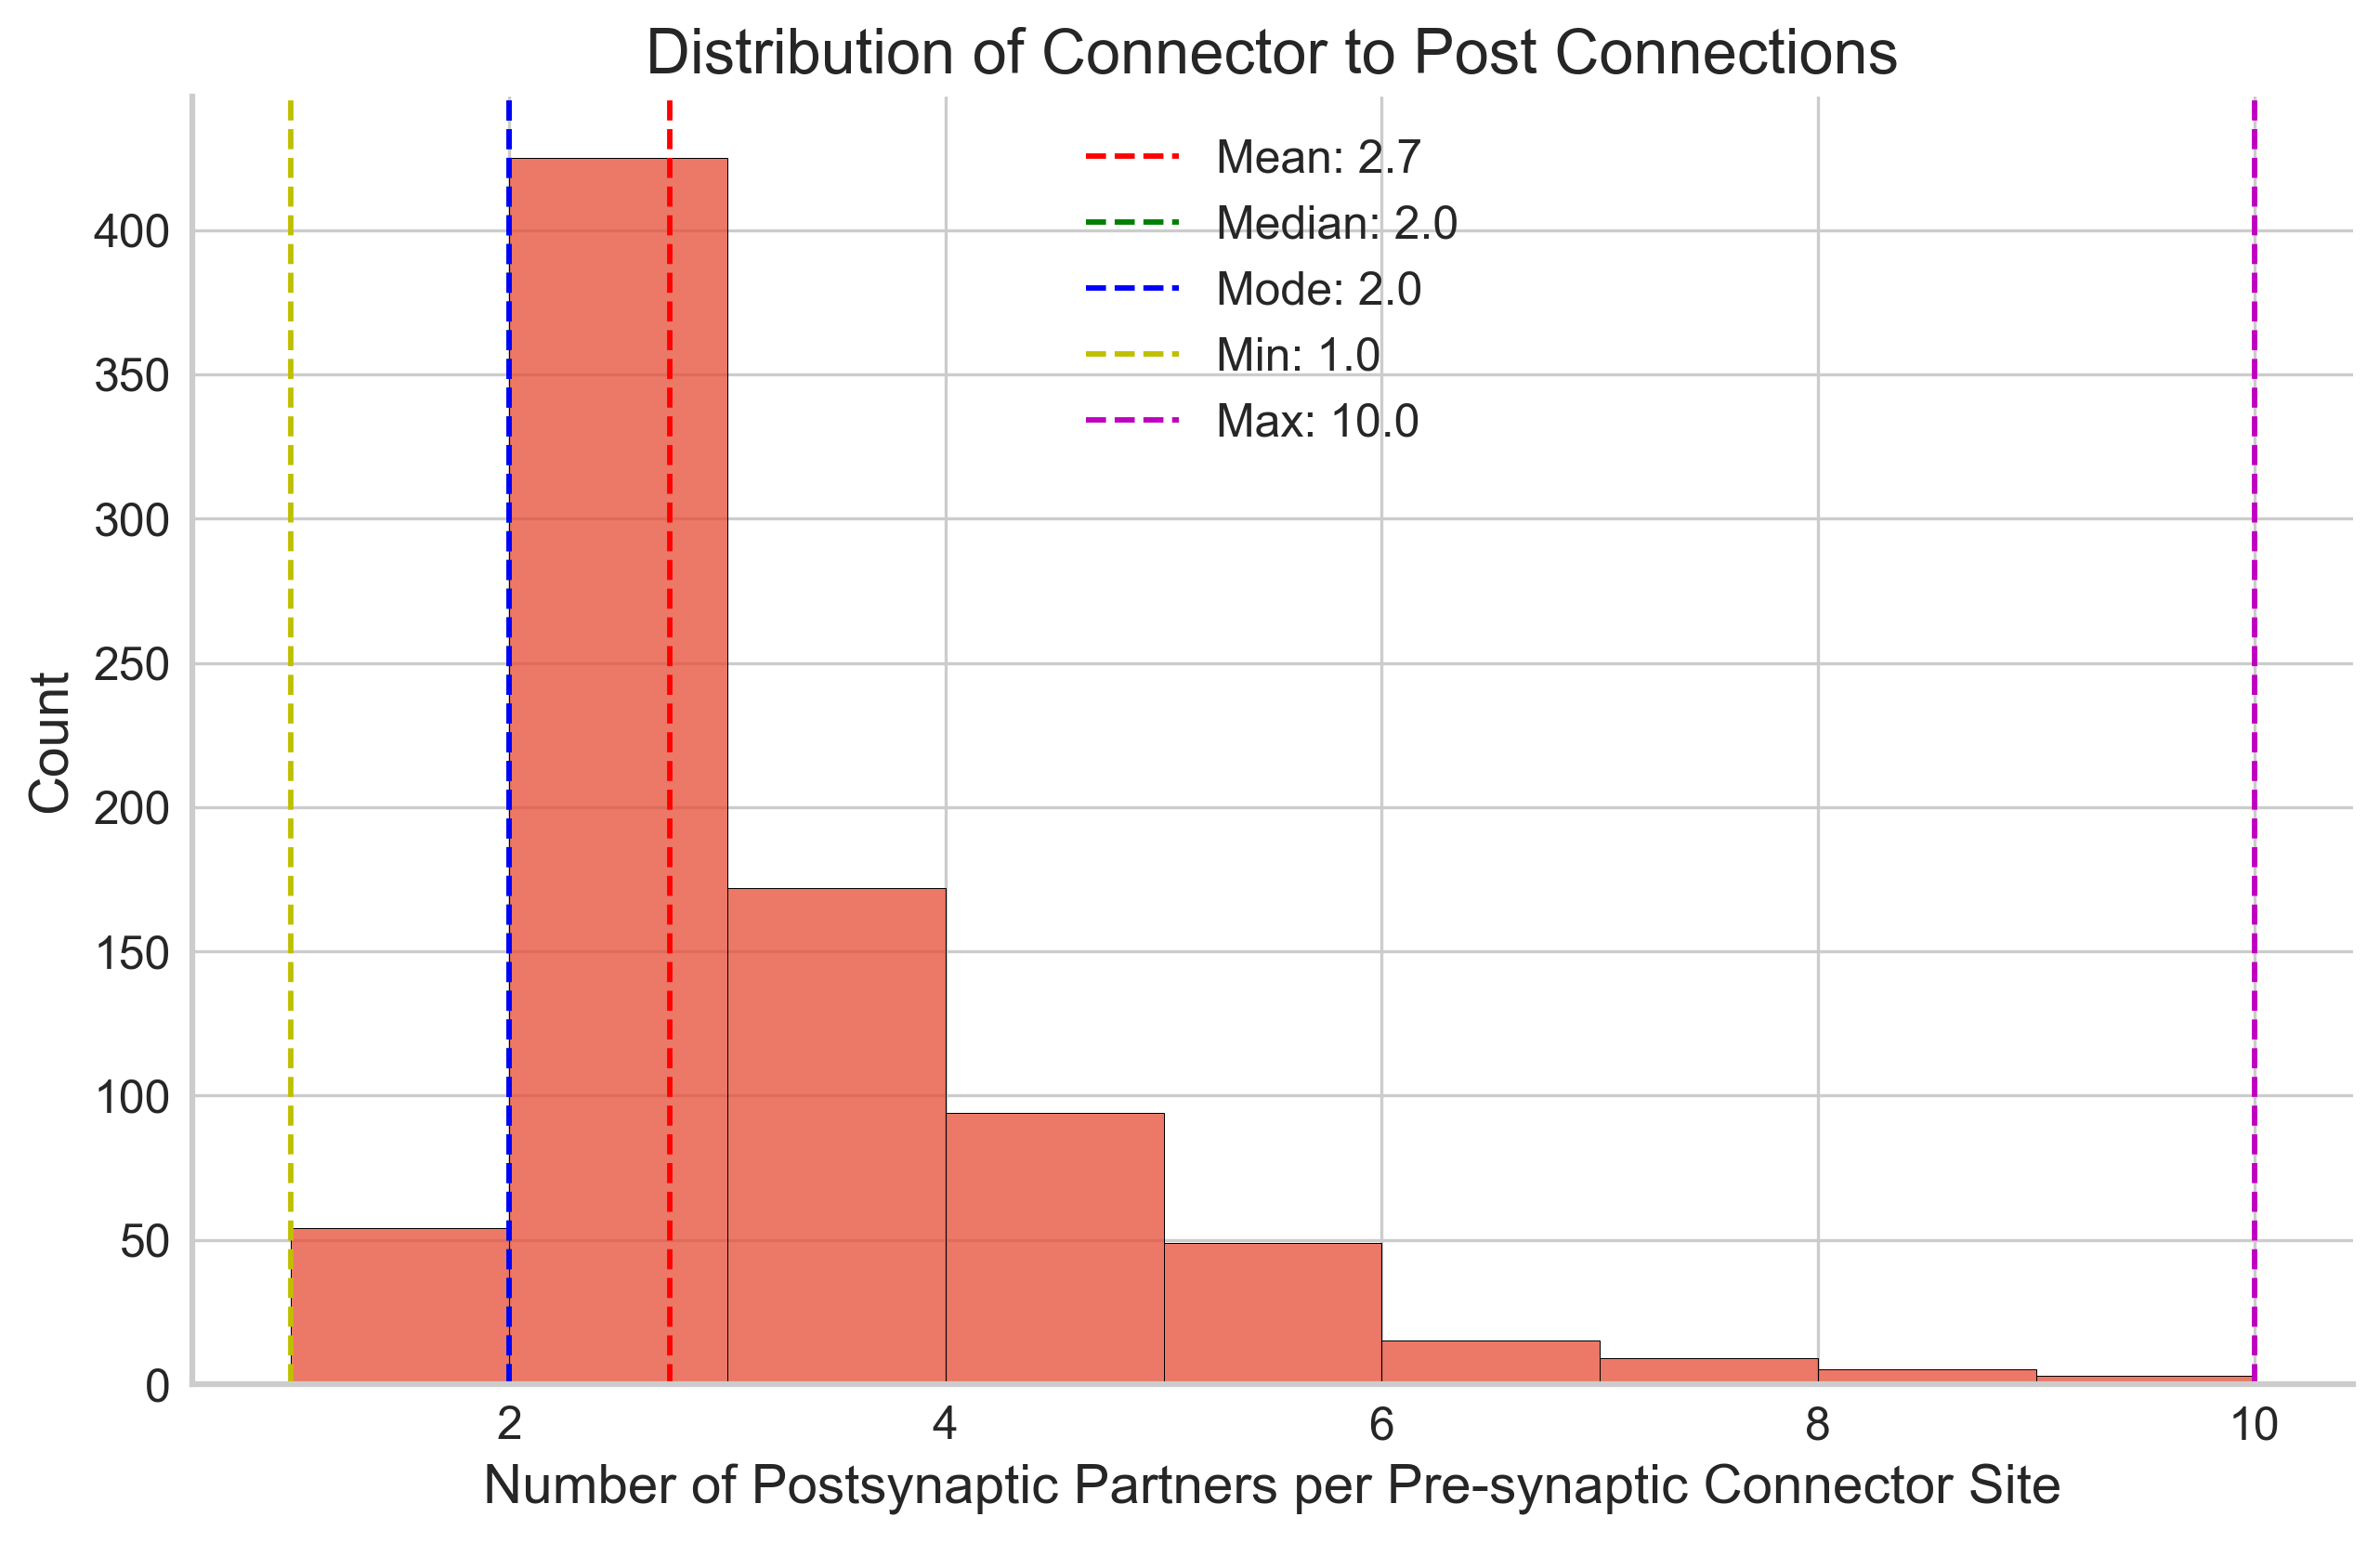


Connectors with maximum (10) post-synaptic partners:

Connector coordinates (z, y, x):
Connector at (1760.0, 1392.0, 2968.0)

Post-synaptic partners:
      pre_neuron  post_x  post_y  post_z  post_neuron
1583         245  1760.0  1528.0  3000.0          246
1584         245  1760.0  1464.0  3168.0          247
1585         245  1800.0  1432.0  3024.0          248
1586         245  1848.0  1376.0  2896.0          249
1587         245  1880.0  1264.0  3088.0          250
1588         245  1880.0  1256.0  2784.0          251
1589         245  1904.0  1176.0  2936.0          252
1590         245  1680.0  1536.0  3128.0          253
1591         245  1648.0  1640.0  3000.0          254
1592         245  1544.0  1672.0  3024.0          255

--------------------------------------------------


In [11]:
import os
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mode

results_output_dir = "/Volumes/SamiaSan/PhD_extras/figs/synapse_analysis_plots/octo"
os.makedirs(results_output_dir, exist_ok=True)


# Verify the df shape remains the same
print(f"shape of all_synapse df {df.shape}")

# 1. Distribution of connectors to post connections
# pre_to_post_counts = df.groupby('pre_neuron')['post_neuron'].count()
pre_to_post_counts = df.groupby(['pre_x', 'pre_y', 'pre_z'])['post_neuron'].count()

# Calculate statistics
mean_pre_to_post = pre_to_post_counts.mean()
median_pre_to_post = pre_to_post_counts.median()
mode_pre_to_post = mode(pre_to_post_counts).mode 
min_pre_to_post = pre_to_post_counts.min()
max_pre_to_post = pre_to_post_counts.max()

print(f'Mean: {mean_pre_to_post:.1f}')
print(f'Median: {median_pre_to_post:.1f}')
print(f'Mode: {mode_pre_to_post:.1f}')
print(f'Min: {min_pre_to_post:.1f}')
print(f'Max: {max_pre_to_post:.1f}')


# Plot the distribution
fig = plt.figure(figsize=(10, 6))
sns.histplot(pre_to_post_counts, kde=False, bins=30, binwidth=1)
plt.axvline(mean_pre_to_post, color='r', linestyle='--', label=f'Mean: {mean_pre_to_post:.1f}')
plt.axvline(median_pre_to_post, color='g', linestyle='--', label=f'Median: {median_pre_to_post:.1f}')
plt.axvline(mode_pre_to_post, color='b', linestyle='--', label=f'Mode: {mode_pre_to_post:.1f}')
plt.axvline(min_pre_to_post, color='y', linestyle='--', label=f'Min: {min_pre_to_post:.1f}')
plt.axvline(max_pre_to_post, color='m', linestyle='--', label=f'Max: {max_pre_to_post:.1f}')
plt.title('Distribution of Connector to Post Connections')
plt.xlabel('Number of Postsynaptic Partners per Pre-synaptic Connector Site')
plt.ylabel('Count')
plt.legend()
sns.despine()
plt.show()
fig.savefig(os.path.join(results_output_dir,'connector_post_connectivity_distributions.svg'))
fig.savefig(os.path.join(results_output_dir,'connector_post_connectivity_distributions.png'))

# Find connectors with maximum post-synaptic partners
max_post_count = pre_to_post_counts.max()
max_connectors = pre_to_post_counts[pre_to_post_counts == max_post_count]

print(f"\nConnectors with maximum ({max_post_count}) post-synaptic partners:")
print("\nConnector coordinates (z, y, x):")
for idx, count in max_connectors.items():
    print(f"Connector at ({idx[0]}, {idx[1]}, {idx[2]})")
    
    # Get all post-synaptic partners for this connector
    post_partners = df[
        (df['pre_x'] == idx[0]) & 
        (df['pre_y'] == idx[1]) & 
        (df['pre_z'] == idx[2])
    ][['pre_neuron', 'post_x', 'post_y', 'post_z', 'post_neuron']]
    
    print("\nPost-synaptic partners:")
    print(post_partners.to_string())
    print("\n" + "-"*50)



In [1]:
# calculate manhattan distances
results_output_dir = "/Volumes/SamiaSan/PhD_extras/figs/synapse_analysis_plots/octo"
os.makedirs(results_output_dir, exist_ok=True)

# Define voxel size
voxel_size = {'x': 8, 'y': 8, 'z': 8}

# Same for connector(stored as pre)-post distances
# Calculate Manhattan distances in physical space (nm)
df['pre_post_distance_nm'] = (np.abs(df['pre_x'] - df['post_x']) + 
                             np.abs(df['pre_y'] - df['post_y']) + 
                             np.abs(df['pre_z'] - df['post_z']))

# Calculate Manhattan distances in voxel space
df['pre_post_distance_voxels'] = (np.abs(df['pre_x']/voxel_size['x'] - df['post_x']/voxel_size['x']) + 
                                 np.abs(df['pre_y']/voxel_size['y'] - df['post_y']/voxel_size['y']) + 
                                 np.abs(df['pre_z']/voxel_size['z'] - df['post_z']/voxel_size['z']))
# Create side-by-side plots for connector-post distances
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 6))
# Add voxel size information
fig.suptitle(f'Voxel size (x,y,z): {voxel_size["x"]}, {voxel_size["y"]}, {voxel_size["z"]} nm', 
             y=1.05, fontsize=14)


# Physical space plot (nm)
sns.histplot(df['pre_post_distance_nm'], kde=False,  bins=30, ax=ax1) 
ax1.axvline(df['pre_post_distance_nm'].mean(), color='r', linestyle='--', 
            label=f'Mean: {df["pre_post_distance_nm"].mean():.2f}')
ax1.axvline(df['pre_post_distance_nm'].median(), color='g', linestyle='--', 
            label=f'Median: {df["pre_post_distance_nm"].median():.2f}')
ax1.axvline(df['pre_post_distance_nm'].max(), color='b', linestyle='--',
                        label=f'Max: {df["pre_post_distance_nm"].max():.2f}')
ax1.set_title('Distribution of Connector-Post Manhattan Distances (nm)')
ax1.set_xlabel('Manhattan Distance (nm)')
ax1.set_ylabel('Count')
ax1.legend()

# Voxel space plot
sns.histplot(df['pre_post_distance_voxels'], kde=False, bins=30, ax=ax2) 
ax2.axvline(df['pre_post_distance_voxels'].mean(), color='r', linestyle='--', 
            label=f'Mean: {df["pre_post_distance_voxels"].mean():.2f}')
ax2.axvline(df['pre_post_distance_voxels'].median(), color='g', linestyle='--', 
            label=f'Median: {df["pre_post_distance_voxels"].median():.2f}')
ax2.axvline(df['pre_post_distance_voxels'].max(), color='b', linestyle='--', 
            label=f'Max: {df["pre_post_distance_voxels"].max():.2f}')
ax2.set_title('Distribution of Connector-Post Manhattan Distances (voxels)')
ax2.set_xlabel('Manhattan Distance (voxels)')

# Ensure both plots have the same y-axis bounds
ax1.set_ylim(0, max(ax1.get_ylim()[1], ax2.get_ylim()[1]))
ax2.set_ylim(0, max(ax1.get_ylim()[1], ax2.get_ylim()[1]))
ax2.legend()

plt.tight_layout()
sns.despine()
plt.show()
fig.savefig(os.path.join(results_output_dir,'mh_connector_post_distance_distributions_both_spaces.svg'))


# Verify total counts
print(f"Total points in nm space: {len(df['pre_post_distance_nm'])}")
print(f"Total points in voxel space: {len(df['pre_post_distance_voxels'])}")

# Check if the relative proportions are preserved
nm_hist, _ = np.histogram(df['pre_post_distance_nm'], bins=30)
voxel_hist, _ = np.histogram(df['pre_post_distance_voxels'], bins=30)
print(f"\nSum of histogram counts in nm space: {nm_hist.sum()}")
print(f"Sum of histogram counts in voxel space: {voxel_hist.sum()}")

NameError: name 'os' is not defined

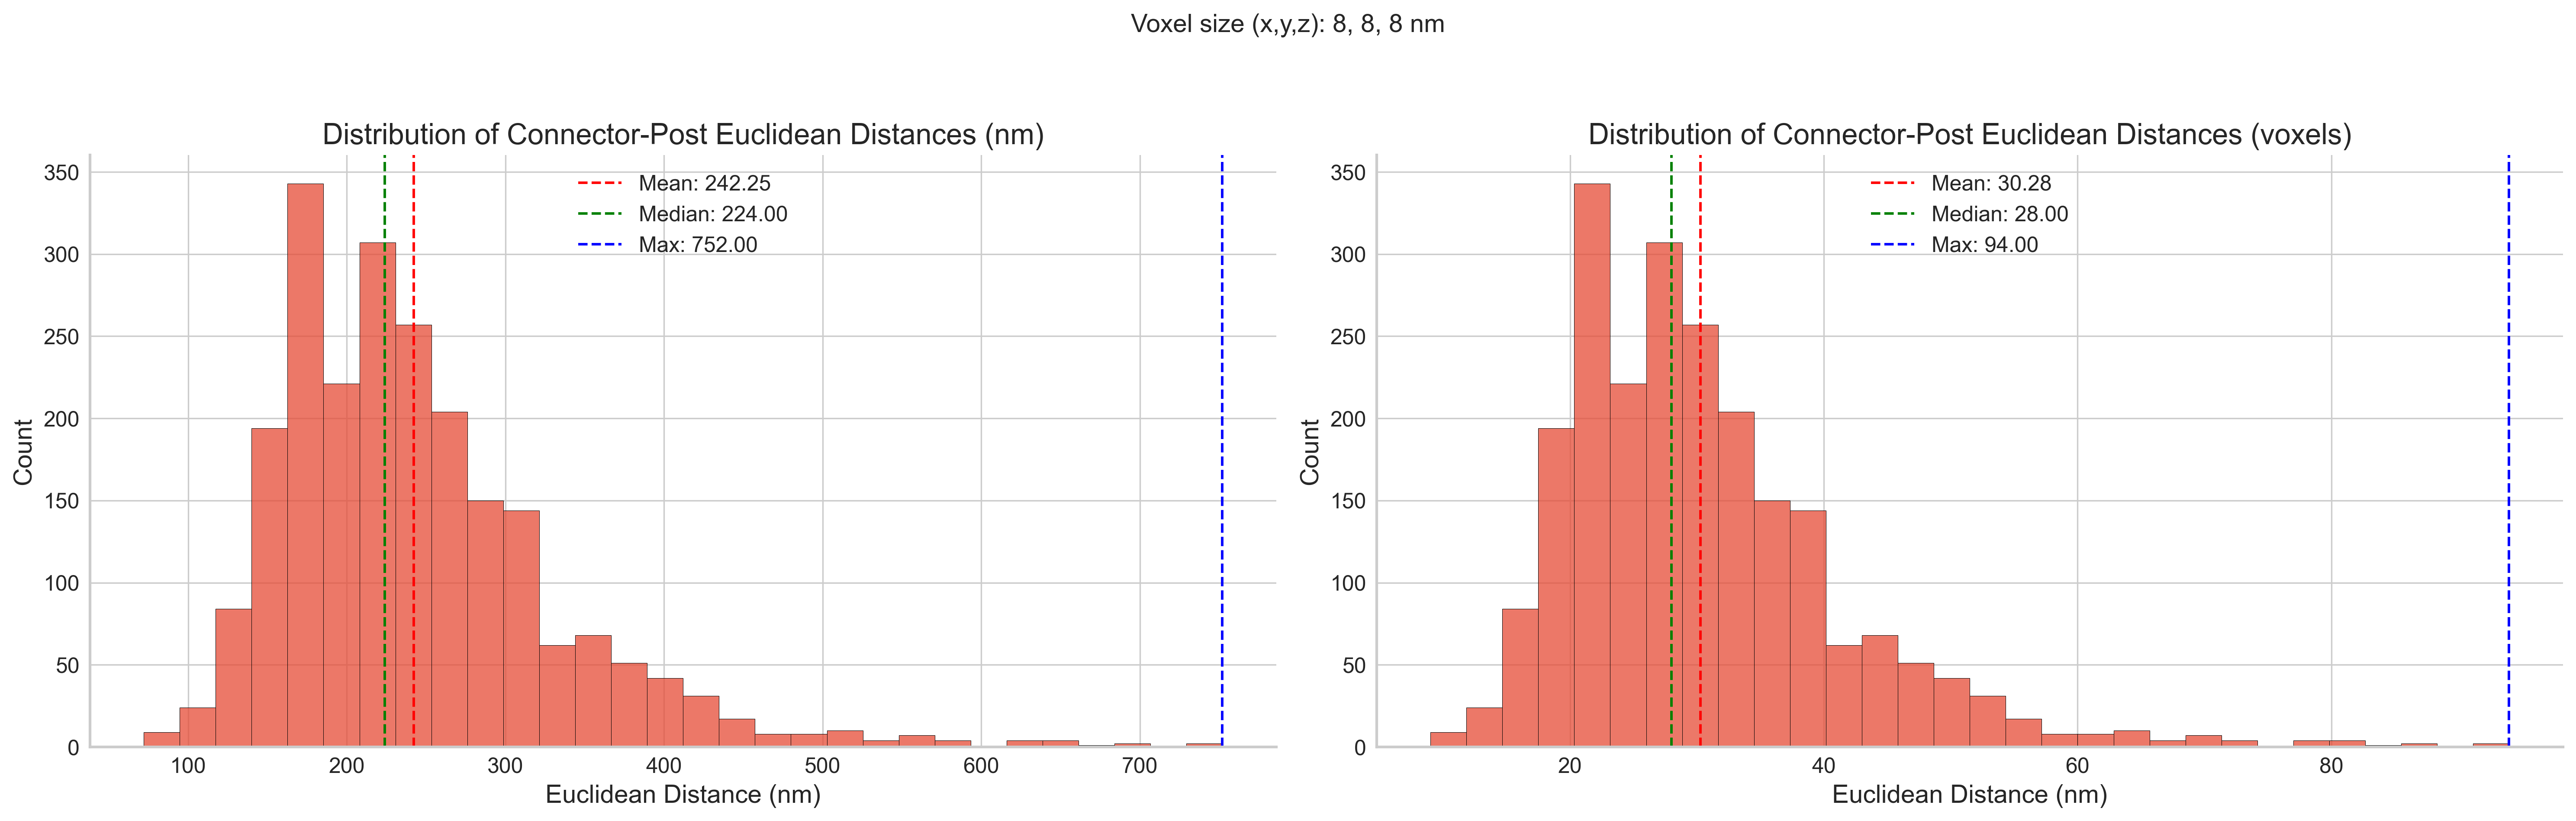

Total points in nm space: 2262
Total points in voxel space: 2262

Sum of histogram counts in nm space: 2262
Sum of histogram counts in voxel space: 2262


In [ ]:
# calculate manhattan distances
results_output_dir = "/Volumes/SamiaSan/PhD_extras/figs/synapse_analysis_plots/octo"
os.makedirs(results_output_dir, exist_ok=True)

# Define voxel size
voxel_size = {'x': 8, 'y': 8, 'z': 8}

# Same for connector(stored as pre)-post distances
# Calculate Euclid distances in physical space (nm)
df['pre_post_distance_nm'] = (np.abs(df['pre_x'] - df['post_x']) + 
                             np.abs(df['pre_y'] - df['post_y']) + 
                             np.abs(df['pre_z'] - df['post_z']))

# Calculate Euclid distances in voxel space
df['pre_post_distance_voxels'] = (np.abs(df['pre_x']/voxel_size['x'] - df['post_x']/voxel_size['x']) + 
                                 np.abs(df['pre_y']/voxel_size['y'] - df['post_y']/voxel_size['y']) + 
                                 np.abs(df['pre_z']/voxel_size['z'] - df['post_z']/voxel_size['z']))
# Create side-by-side plots for connector-post distances
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 6))
# Add voxel size information
fig.suptitle(f'Voxel size (x,y,z): {voxel_size["x"]}, {voxel_size["y"]}, {voxel_size["z"]} nm', 
             y=1.05, fontsize=14)


# Physical space plot (nm)
sns.histplot(df['pre_post_distance_nm'], kde=False,  bins=30, ax=ax1) 
ax1.axvline(df['pre_post_distance_nm'].mean(), color='r', linestyle='--', 
            label=f'Mean: {df["pre_post_distance_nm"].mean():.2f}')
ax1.axvline(df['pre_post_distance_nm'].median(), color='g', linestyle='--', 
            label=f'Median: {df["pre_post_distance_nm"].median():.2f}')
ax1.axvline(df['pre_post_distance_nm'].max(), color='b', linestyle='--', 
            label=f'Max: {df["pre_post_distance_nm"].max():.2f}')
ax1.set_title('Distribution of Connector-Post Euclidean Distances (nm)')
ax1.set_xlabel('Euclidean Distance (nm)')
ax1.set_ylabel('Count')
ax1.legend()

# Voxel space plot
sns.histplot(df['pre_post_distance_voxels'], kde=False, bins=30, ax=ax2) 
ax2.axvline(df['pre_post_distance_voxels'].mean(), color='r', linestyle='--', 
            label=f'Mean: {df["pre_post_distance_voxels"].mean():.2f}')
ax2.axvline(df['pre_post_distance_voxels'].median(), color='g', linestyle='--', 
            label=f'Median: {df["pre_post_distance_voxels"].median():.2f}')
ax2.axvline(df['pre_post_distance_voxels'].max(), color='b', linestyle='--', 
            label=f'Max: {df["pre_post_distance_voxels"].max():.2f}')
ax2.set_title('Distribution of Connector-Post Euclidean Distances (voxels)')
ax2.set_xlabel('Euclidean Distance (voxels)')
# Ensure both plots have the same y-axis bounds
ax1.set_ylim(0, max(ax1.get_ylim()[1], ax2.get_ylim()[1]))
ax2.set_ylim(0, max(ax1.get_ylim()[1], ax2.get_ylim()[1]))
ax2.legend()

plt.tight_layout()
sns.despine()
plt.show()
fig.savefig(os.path.join(results_output_dir,'euclid_connector_post_distance_distributions_both_spaces.svg'))


# Verify total counts
print(f"Total points in nm space: {len(df['pre_post_distance_nm'])}")
print(f"Total points in voxel space: {len(df['pre_post_distance_voxels'])}")

# Check if the relative proportions are preserved
nm_hist, _ = np.histogram(df['pre_post_distance_nm'], bins=30)
voxel_hist, _ = np.histogram(df['pre_post_distance_voxels'], bins=30)
print(f"\nSum of histogram counts in nm space: {nm_hist.sum()}")
print(f"Sum of histogram counts in voxel space: {voxel_hist.sum()}")

3

Dataset: /Volumes/SamiaSan/PhD_Data/Synapses/octo/octo_cube1_8083_8765_y5878_6542_z4697_5319.hdf
Volume: 144.22 cubic microns
Number of synapses: 542
Density: 3.76 synapses/cubic micron

Dataset: /Volumes/SamiaSan/PhD_Data/Synapses/octo/octo_cube3_calyx_5603_6267_y3254_3890_z7464_8163.hdf
Volume: 151.14 cubic microns
Number of synapses: 850
Density: 5.62 synapses/cubic micron

Dataset: /Volumes/SamiaSan/PhD_Data/Synapses/octo/octo_cube2_12485_13164_y6231_6901_z3971_4640.hdf
Volume: 155.83 cubic microns
Number of synapses: 870
Density: 5.58 synapses/cubic micron


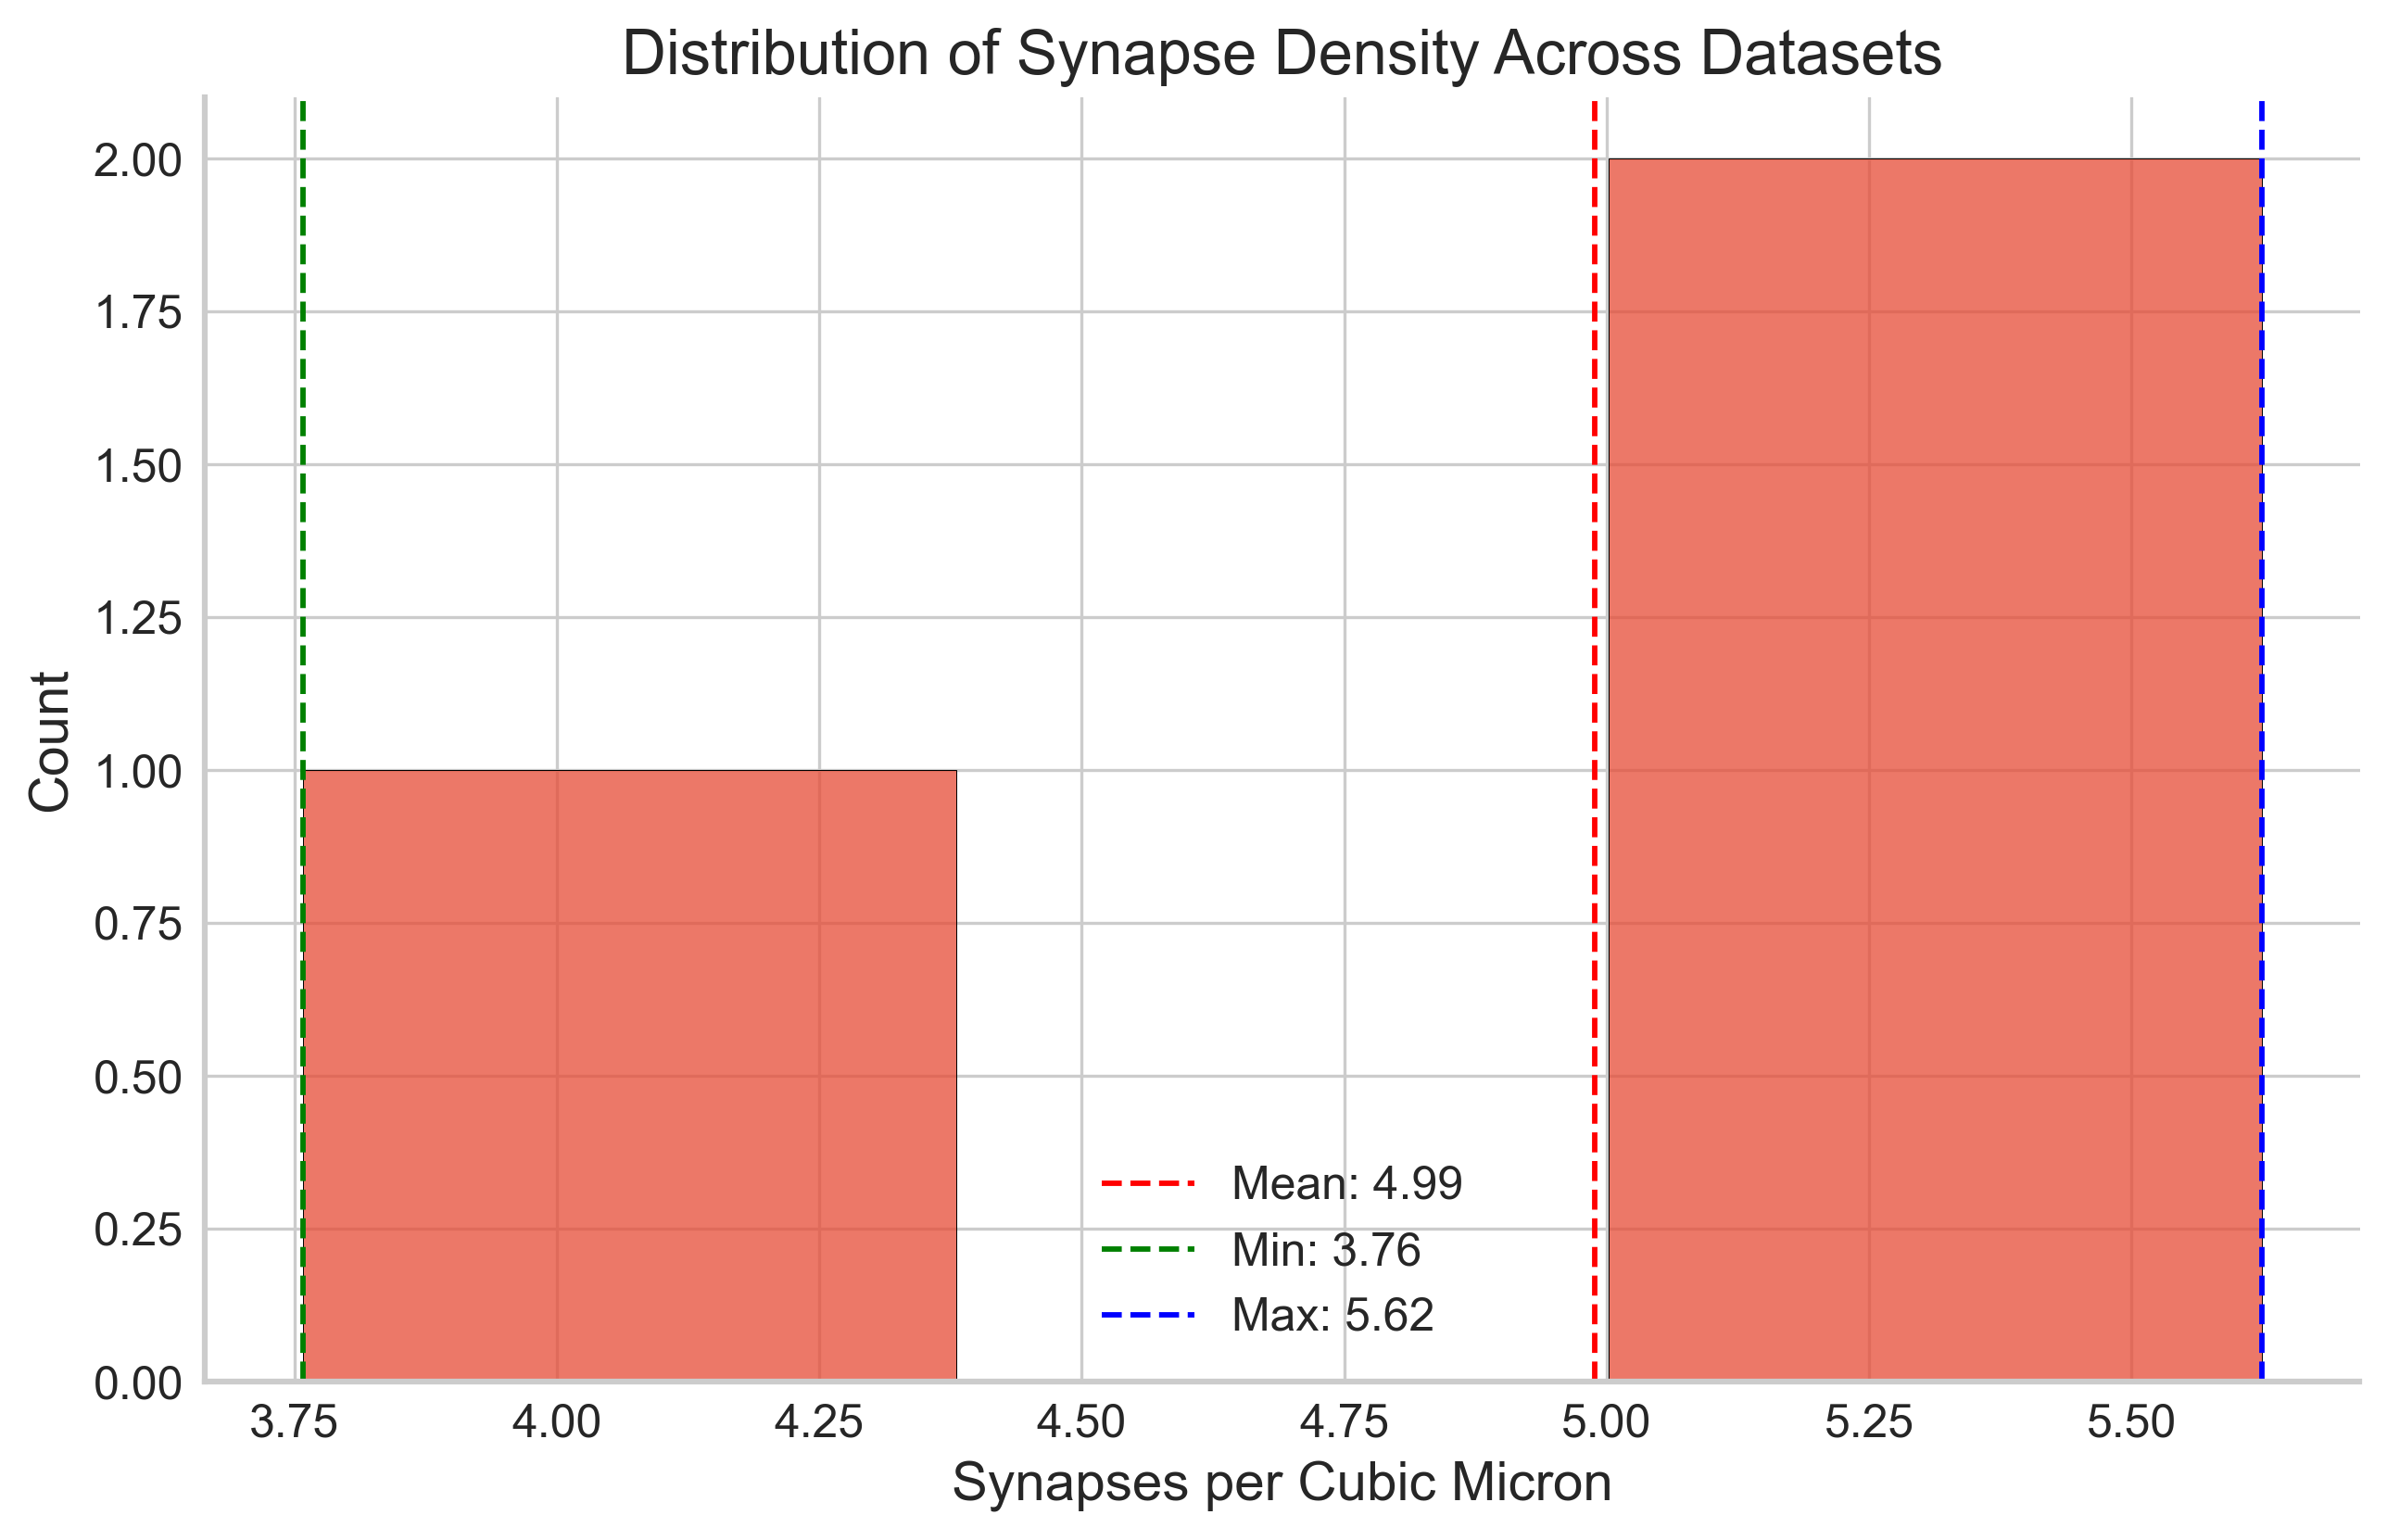


Summary of all datasets:
                                                name      volume  synapses  \
1  /Volumes/SamiaSan/PhD_Data/Synapses/octo/octo_...  151.137534       850   
2  /Volumes/SamiaSan/PhD_Data/Synapses/octo/octo_...  155.826263       870   
0  /Volumes/SamiaSan/PhD_Data/Synapses/octo/octo_...  144.215785       542   

    density  
1  5.624017  
2  5.583141  
0  3.758257  


In [24]:
# Read synapse data and calculate density for each dataset
densities = []
dataset_info = []

print(len(shapes.keys()))

for filename in hdf_files:
    csv_filename = os.path.splitext(filename)[0] + '_synapses.csv'
    if os.path.exists(csv_filename):
        # Read dataset
        df = pd.read_csv(csv_filename)
        dataset_name = filename
        
        # Get dataset's dimensions and calculate volume
        dataset_microns = calculate_microns(shapes[dataset_name], 8)
        volume = np.prod(dataset_microns)
        
        # Calculate density
        num_synapses = len(df)
        density = num_synapses / volume
        
        densities.append(density)
        dataset_info.append({
            'name': dataset_name,
            'volume': volume,
            'synapses': num_synapses,
            'density': density
        })
        
        print(f"\nDataset: {dataset_name}")
        print(f"Volume: {volume:.2f} cubic microns")
        print(f"Number of synapses: {num_synapses:,}")
        print(f"Density: {density:.2f} synapses/cubic micron")

# Plot the distribution
fig = plt.figure(figsize=(10, 6))
sns.histplot(densities, kde=False, bins=len(densities))
plt.axvline(np.mean(densities), color='r', linestyle='--', 
            label=f'Mean: {np.mean(densities):.2f}')
plt.axvline(np.min(densities), color='g', linestyle='--', 
            label=f'Min: {np.min(densities):.2f}')
plt.axvline(np.max(densities), color='b', linestyle='--', 
            label=f'Max: {np.max(densities):.2f}')
plt.title('Distribution of Synapse Density Across Datasets')
plt.xlabel('Synapses per Cubic Micron')
plt.ylabel('Count')
plt.legend()
sns.despine()
plt.show()

# Create a summary DataFrame
summary_df = pd.DataFrame(dataset_info)
print("\nSummary of all datasets:")
print(summary_df.sort_values('density', ascending=False))

In [8]:
# Read synapse data and calculate density for each dataset
densities = []
dataset_info = []

print(len(shapes.keys()))

for filename in hdf_files:
    csv_filename = os.path.splitext(filename)[0] + '_synapses.csv'
    if os.path.exists(csv_filename):
        # Read dataset
        df = pd.read_csv(csv_filename)
        dataset_name = filename
        
        # Get dataset's dimensions and calculate volume
        dataset_microns = calculate_microns(shapes[dataset_name], 8)
        volume = np.prod(dataset_microns)
        
        # Calculate density
        num_synapses = len(df)
        density = num_synapses / volume
        
        densities.append(density)
        dataset_info.append({
            'name': dataset_name,
            'volume': volume,
            'synapses': num_synapses,
            'density': density
        })
        
        print(f"\nDataset: {dataset_name}")
        print(f"Volume: {volume:.2f} cubic microns")
        print(f"Number of synapses: {num_synapses:,}")
        print(f"Density: {density:.2f} synapses/cubic micron")

# Use the above data to create a swarm plot
summary_df = pd.DataFrame(dataset_info)
summary_df['short_name'] = [f'Dataset {i+1}' for i in range(len(summary_df))]

summary_df.head()

fig, ax = plt.subplots(figsize=(8, 6))
sns.swarmplot(data=summary_df, x='short_name', y='density', ax=ax)
ax.set_title('Swarm Plot of Synapse Density per Cubic Micron')
ax.set_xlabel('Dataset')
ax.set_ylabel('Synapse Density (synapses/µm³)')
plt.tight_layout()
plt.show()
fig.savefig(os.path.join(results_output_dir, 'synapse_density_swarm_plot.svg'))

NameError: name 'shapes' is not defined

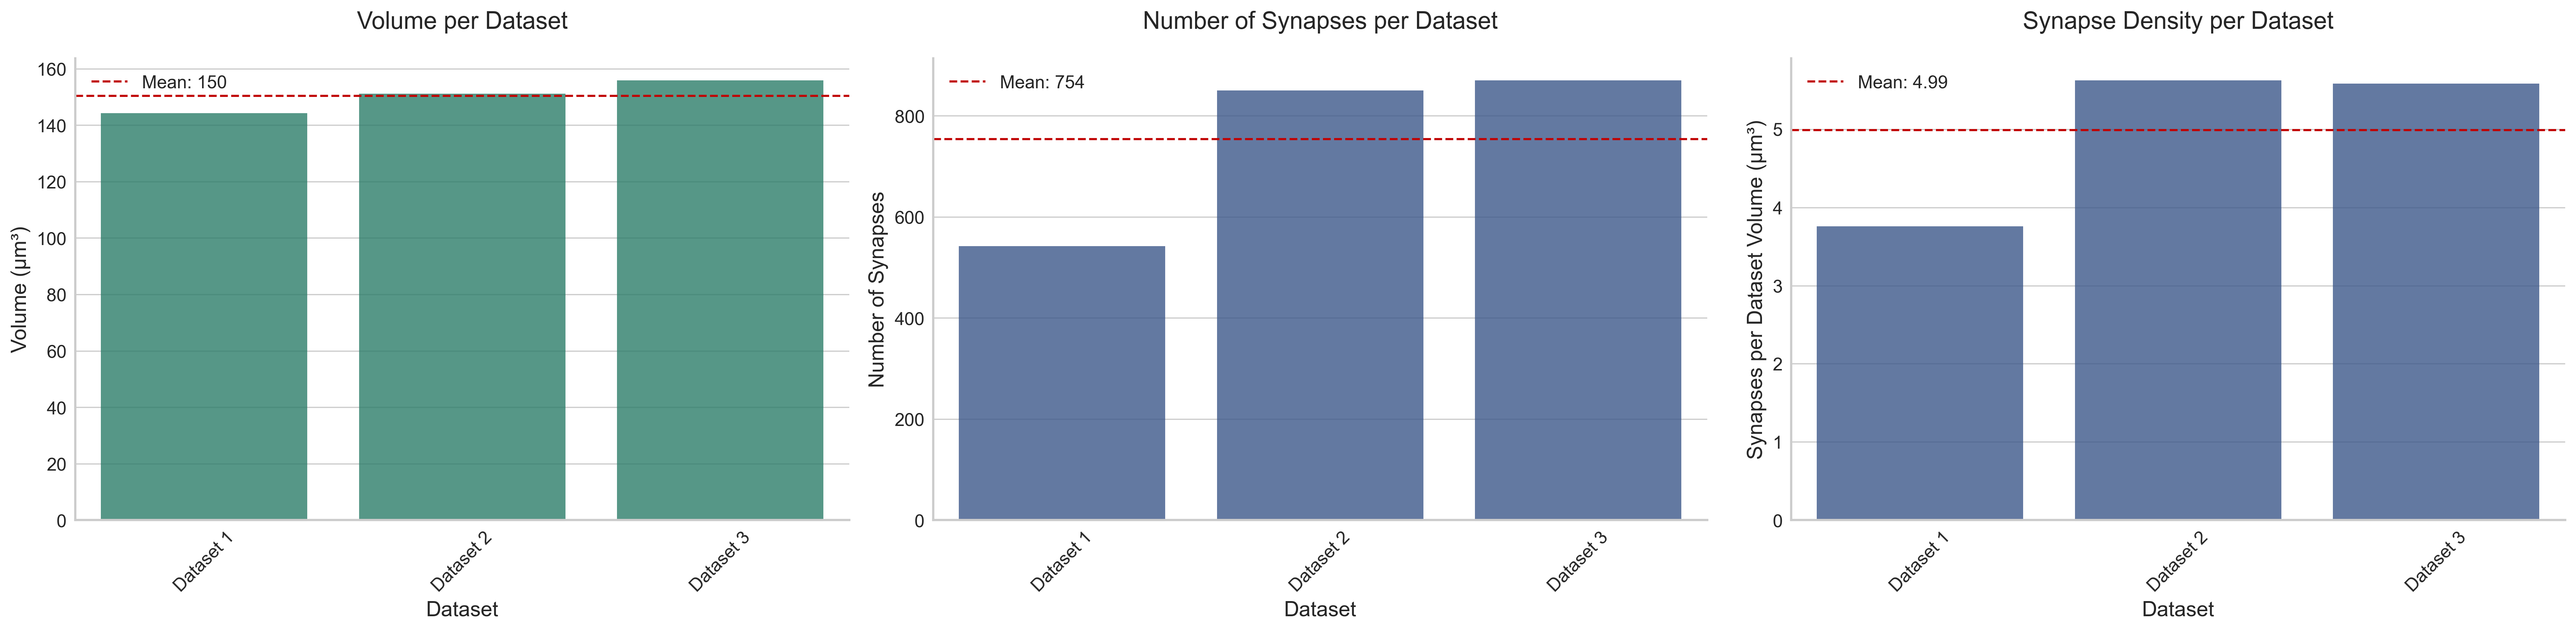

In [28]:
# Create three side-by-side plots
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(24, 6))

# Use professional color palette
scientific_color = '#2F5597'  # Deep blue
mean_line_color = '#C00000'   # Deep red
volume_color = '#1F8A70'      # Complementary teal color

# Convert dataset names to shorter versions
summary_df['short_name'] = [f'Dataset {i+1}' for i in range(len(summary_df))]

# Plot 1: Volume in microns per dataset
sns.barplot(data=summary_df, x='short_name', y='volume', ax=ax1, color=volume_color, alpha=0.8)
ax1.axhline(summary_df['volume'].mean(), color=mean_line_color, linestyle='--', 
            label=f'Mean: {summary_df["volume"].mean():,.0f}')
ax1.set_title('Volume per Dataset', pad=20)
ax1.set_xlabel('Dataset')
ax1.set_ylabel('Volume (µm³)')
ax1.tick_params(axis='x', rotation=45)
ax1.legend(frameon=False)

# Plot 2: Number of synapses per dataset
sns.barplot(data=summary_df, x='short_name', y='synapses', ax=ax2, color=scientific_color, alpha=0.8)
ax2.axhline(summary_df['synapses'].mean(), color=mean_line_color, linestyle='--', 
            label=f'Mean: {summary_df["synapses"].mean():,.0f}')
ax2.set_title('Number of Synapses per Dataset', pad=20)
ax2.set_xlabel('Dataset')
ax2.set_ylabel('Number of Synapses')
ax2.tick_params(axis='x', rotation=45)
ax2.legend(frameon=False)

# Plot 3: Density per dataset
sns.barplot(data=summary_df, x='short_name', y='density', ax=ax3, color=scientific_color, alpha=0.8)
ax3.axhline(summary_df['density'].mean(), color=mean_line_color, linestyle='--', 
            label=f'Mean: {summary_df["density"].mean():.2f}')
ax3.set_title('Synapse Density per Dataset', pad=20)
ax3.set_xlabel('Dataset')
ax3.set_ylabel('Synapses per Dataset Volume (µm³)')
ax3.tick_params(axis='x', rotation=45)
ax3.legend(frameon=False)



plt.tight_layout()
sns.despine()
plt.show()
fig.savefig(os.path.join(results_output_dir,'synapse_density_per_dataset.svg'))